# **Análise entre Expectativa de vida ao nascer e Média de idade no Brasil**

As hipóteses formuladas antes de obter os dados são de que a expectativa de vida ao nascer irá aumentar e por consequência disso a média de idade também aumente. A segunda é que no ano de 2021, tanto a média quanto a expectativa de vida serão menores do que nos anos anteriores por conta da pandemia.

Expectativa de vida ao nascer no Brasil:
2000    71.2
2001    71.5
2002    71.8
2003    72.0
2004    72.3
Name: 23, dtype: float64
Média de idade no Brasil:
2000    24.2
2001    24.5
2002    24.9
2003    25.2
2004    25.6
Name: 27, dtype: float64
Estatísticas básicas da Expectativa de vida ao nascer no Brasil no Periodo de 2000 a 2023:
count    24.00
mean     73.83
std       1.44
min      71.20
25%      73.02
50%      73.85
75%      74.85
max      76.70
Name: 23, dtype: object
Estatísticas básicas da Média de idade no Brasil no Periodo de 2000 a 2023:
count    24.00
mean     28.93
std       3.08
min      24.20
25%      26.30
50%      28.90
75%      31.50
max      33.90
Name: 27, dtype: object


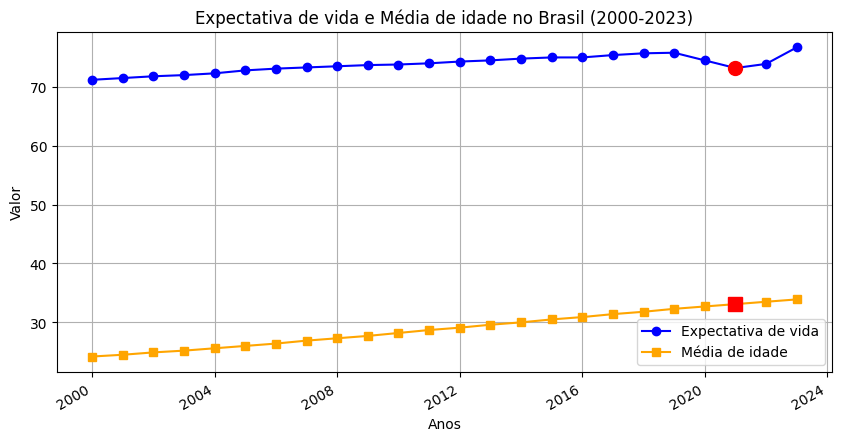

Coeficiente de correlação (r): 0.8412
Coeficiente de determinação (R²): 0.7076


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Lê os CSV
df_lex = pd.read_csv("https://drive.google.com/u/3/uc?id=17JI4Uc_bfvlKSn4lyWt0LJwkx8b5GXd3&export=download")
df_may = pd.read_csv('https://drive.google.com/u/3/uc?id=1NszN85zv_dQ00pgHUHHwJ-tkX_4rSL76&export=download')

# Filtra a linha do Brasil
linha_brazil_lex = df_lex[df_lex['country'] == 'Brazil']
linha_brazil_may = df_may[df_may['country'] == 'Brazil']

# Seleciona os anos desejados como strings
anos = [str(ano) for ano in range(2000, 2024)]


# Pega os valores esses anos
faixa_lex = linha_brazil_lex[anos].iloc[0]
faixa_may = linha_brazil_may[anos].iloc[0]

# Converte os anos para datetime (necessário para matplotlib dates)
anos_dt = pd.to_datetime(anos, format='%Y')

# Exibe os 5 primeiros anos e valores
print("Expectativa de vida ao nascer no Brasil:")
print(faixa_lex.head(5))
print("Média de idade no Brasil:")
print(faixa_may.head(5))

# Exibe as estatísticas básicas dos dados no Brasil
print("Estatísticas básicas da Expectativa de vida ao nascer no Brasil no Periodo de 2000 a 2023:")
print(faixa_lex.describe().map(lambda x: f"{x:.2f}"))
print("Estatísticas básicas da Média de idade no Brasil no Periodo de 2000 a 2023:")
print(faixa_may.describe().map(lambda x: f"{x:.2f}"))

# Codigos para o gráfico
plt.figure(figsize=(10,5))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()
plt.plot(anos_dt, faixa_lex, '-o', color='blue', label='Expectativa de vida')
plt.plot(anos_dt, faixa_may, '-s', color='orange', label='Média de idade')
plt.plot(pd.to_datetime('2021'), faixa_lex['2021'], 'ro', markersize=10) #Destaque para o ano escolhido na análise
plt.plot(pd.to_datetime('2021'), faixa_may['2021'], 'rs', markersize=10)
plt.xlabel("Anos")
plt.ylabel("Valor")
plt.title("Expectativa de vida e Média de idade no Brasil (2000-2023)")
plt.legend()
plt.grid(True)
plt.show()

#Aplicando Regressão, correlação e determinação
x = faixa_may.values
y = faixa_lex.values
(a, b) = np.polyfit(x, y, 1)
ccor = np.corrcoef(x, y)[0, 1]
cdet = ccor ** 2
print(f"Coeficiente de correlação (r): {ccor:.4f}")
print(f"Coeficiente de determinação (R²): {cdet:.4f}")

**Resultados finais**

A primeira hipótese formulada de que a expectativa de vida aumenta junto da média de idade foi refutada. mesmo q o coeficiente de correlação ficou alto, nos anos de pandemia a expectativa de vida ao nascer caiu e a média de idade não diminuiu, mesmo que esses dados aumentem durante os anos, eles não têm ligação entre si apenas sendo uma coincidência . agora a segunda hipótese foi em partes refutada, a expectativa de vida ao nascer diminuiu porém a média continuou aumentando, sem muita alteração